# SVM model

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier as GBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pickle
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import  TimeSeriesSplit


In [2]:
data = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')

In [4]:
df = pd.DataFrame(data)
df.tail()

,time,open,high,low,close,tick_volume
28474,2024-12-04 05:18:00,1.04969,1.04978,1.04969,1.04977,19
28475,2024-12-04 05:19:00,1.04978,1.04979,1.04962,1.04965,26
28476,2024-12-04 05:20:00,1.04964,1.04971,1.04962,1.04962,28
28477,2024-12-04 05:21:00,1.04962,1.04969,1.04962,1.04963,17
28478,2024-12-04 05:22:00,1.04962,1.04967,1.04957,1.04957,13


In [6]:
# df.iloc(19903)
print(df.loc[[19903]])

                      time    open     high      low    close  tick_volume
19903  2024-11-22 01:17:00  1.0473  1.04732  1.04727  1.04729           12


In [12]:
df.shape

(28479, 6)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28479 entries, 0 to 28478
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         28479 non-null  object 
 1   open         28479 non-null  float64
 2   high         28479 non-null  float64
 3   low          28479 non-null  float64
 4   close        28479 non-null  float64
 5   tick_volume  28479 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.3+ MB


In [14]:
df.isnull().sum() #to check null values

time           0
open           0
high           0
low            0
close          0
tick_volume    0
dtype: int64

In [15]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
28474    False
28475    False
28476    False
28477    False
28478    False
Length: 28479, dtype: bool

In [16]:
def detect_outliers(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        # Drop NaN values for this calculation
        col_data = df[column].dropna()

        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers[column] = col_data[(col_data < lower_bound) | (col_data > upper_bound)]

    return outliers

outliers_found = detect_outliers(df)

# Display the results
for column, outliers in outliers_found.items():
    print(f"Outliers in {column}:")
    print(outliers)
    print("\n")


Outliers in open:
Series([], Name: open, dtype: float64)


Outliers in high:
Series([], Name: high, dtype: float64)


Outliers in low:
Series([], Name: low, dtype: float64)


Outliers in close:
Series([], Name: close, dtype: float64)


Outliers in tick_volume:
2132     111
2685      84
2686      98
2687      80
2688      80
        ... 
27686    101
27920     86
28096     80
28097     82
28104     80
Name: tick_volume, Length: 432, dtype: int64




In [13]:
# Duplicate the column
df['Adj Close'] = df['close']
df

,time,open,high,low,close,tick_volume,Adj Close
0,2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29,1.09002
1,2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28,1.09000
2,2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25,1.08995
3,2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15,1.08990
4,2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16,1.08995
...,...,...,...,...,...,...,...
28474,2024-12-04 05:18:00,1.04969,1.04978,1.04969,1.04977,19,1.04977
28475,2024-12-04 05:19:00,1.04978,1.04979,1.04962,1.04965,26,1.04965
28476,2024-12-04 05:20:00,1.04964,1.04971,1.04962,1.04962,28,1.04962
28477,2024-12-04 05:21:00,1.04962,1.04969,1.04962,1.04963,17,1.04963


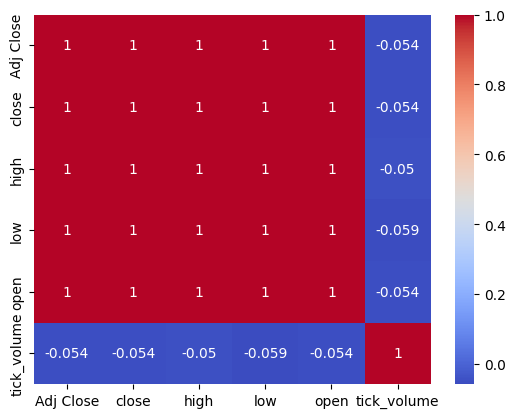

In [18]:
corr_matrix = df[['Adj Close', 'close', 'high', 'low', 'open', 'tick_volume']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [19]:
df.describe()

,open,high,low,close,tick_volume,Adj Close
count,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000
mean,1.061434,1.061519,1.061346,1.061433,31.212859,1.061433
std,0.012932,0.012926,0.012938,0.012932,18.711259,0.012932
min,1.033990,1.035660,1.033130,1.033980,1.000000,1.033980
25%,1.053170,1.053270,1.053070,1.053170,17.000000,1.053170
50%,1.056740,1.056830,1.056650,1.056740,28.000000,1.056740
75%,1.071035,1.071140,1.070960,1.071030,42.000000,1.071030
max,1.093640,1.093690,1.093540,1.093640,169.000000,1.093640


In [20]:
df.columns

Index(['time', 'open', 'high', 'low', 'close', 'tick_volume', 'Adj Close'], dtype='object')

## Feature engineering

In [14]:
# Calculate 50-day and 200-day SMA and EMA
df['SMA50'] = df['close'].rolling(window=50).mean()
df['SMA200'] = df['close'].rolling(window=200).mean()

# Check results
print("SMA50:", df['SMA50'].head(60))  # Display first 60 rowsa

# Check for empty or NaN values in SMA
print("SMA50 NaN counts:", df['SMA50'].isna().sum())

# Calculate EMA (50 and 200-day)
df['EMA50'] = df['close'].ewm(span=50, adjust=False).mean()
df['EMA200'] = df['close'].ewm(span=200, adjust=False).mean()

# Check results for EMA
print("EMA50:", df['EMA50'].head(60))  # Display first 60 rows

# Check for empty or NaN values in EMA
print("EMA50 NaN counts:", df['EMA50'].isna().sum())


SMA50: 0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24         NaN
25         NaN
26         NaN
27         NaN
28         NaN
29         NaN
30         NaN
31         NaN
32         NaN
33         NaN
34         NaN
35         NaN
36         NaN
37         NaN
38         NaN
39         NaN
40         NaN
41         NaN
42         NaN
43         NaN
44         NaN
45         NaN
46         NaN
47         NaN
48         NaN
49    1.090102
50    1.090103
51    1.090103
52    1.090102
53    1.090101
54    1.090099
55    1.090099
56    1.090100
57    1.090100
58    1.090102
59    1.090106
Name: SMA50, dtype: float64
SMA50 NaN counts: 49
EMA50: 0     1.090020
1     1.090019
2     1

In [22]:
df.head()

,time,open,high,low,close,tick_volume,Adj Close,SMA50,SMA200,EMA50,EMA200
0,2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29,1.09002,NaN,NaN,1.090020,1.090020
1,2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28,1.09000,NaN,NaN,1.090019,1.090020
2,2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25,1.08995,NaN,NaN,1.090017,1.090019
3,2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15,1.08990,NaN,NaN,1.090012,1.090018
4,2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16,1.08995,NaN,NaN,1.090010,1.090017


In [23]:
df.isnull().sum() #to check null values

time             0
open             0
high             0
low              0
close            0
tick_volume      0
Adj Close        0
SMA50           49
SMA200         199
EMA50            0
EMA200           0
dtype: int64

In [15]:
df.dropna(subset=['SMA50'], inplace=True)


In [16]:
df.dropna(subset=['SMA200'], inplace=True)


In [26]:
df.describe()

,open,high,low,close,tick_volume,Adj Close,SMA50,SMA200,EMA50,EMA200
count,28280.000000,28280.000000,28280.000000,28280.000000,28280.000000,28280.000000,28280.000000,28280.000000,28280.000000,28280.000000
mean,1.061234,1.061320,1.061146,1.061233,31.309477,1.061233,1.061268,1.061372,1.061268,1.061372
std,0.012756,0.012750,0.012760,0.012755,18.733666,0.012755,0.012769,0.012813,0.012764,0.012796
min,1.033990,1.035660,1.033130,1.033980,1.000000,1.033980,1.039719,1.040686,1.039871,1.040676
25%,1.053138,1.053240,1.053030,1.053140,17.000000,1.053140,1.053152,1.053251,1.053124,1.053321
50%,1.056680,1.056770,1.056590,1.056670,28.000000,1.056670,1.056668,1.056612,1.056655,1.056591
75%,1.070660,1.070762,1.070483,1.070650,42.000000,1.070650,1.070809,1.071098,1.070796,1.071368
max,1.093640,1.093690,1.093540,1.093640,169.000000,1.093640,1.093370,1.093008,1.093291,1.092707


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28280 entries, 199 to 28478
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         28280 non-null  object 
 1   open         28280 non-null  float64
 2   high         28280 non-null  float64
 3   low          28280 non-null  float64
 4   close        28280 non-null  float64
 5   tick_volume  28280 non-null  int64  
 6   Adj Close    28280 non-null  float64
 7   SMA50        28280 non-null  float64
 8   SMA200       28280 non-null  float64
 9   EMA50        28280 non-null  float64
 10  EMA200       28280 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 2.6+ MB


In [17]:
df.loc[:, 'SMA_5'] = df['close'].rolling(window=5).mean()
df.loc[:, 'SMA_10'] = df['close'].rolling(window=10).mean()
df.loc[:, 'SMA_20'] = df['close'].rolling(window=20).mean()

df.loc[:, 'EMA_5'] = df['close'].ewm(span=5, adjust=False).mean()
df.loc[:, 'EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()

df.loc[:, 'ROC_5'] = df['close'].pct_change(periods=5)
df.loc[:, 'Price_Change'] = df['close'].pct_change()
df.loc[:, 'Lag_1'] = df['close'].shift(1)
df.loc[:, 'Volatility_5'] = df['close'].rolling(window=5).std()
df.loc[:, 'Cumulative_Returns'] = (1 + df['Price_Change']).cumprod() - 1
df.loc[:, 'Volume_SMA_7'] = df['tick_volume'].rolling(window=7).mean()

df = df.dropna()

X = df[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change', 'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7']]
y = df['close']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [29]:
# Prepare feature set and target variable
X = df[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change',
          'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7']]
y = df['close']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the model
svm_model = SVR()

# Define hyperparameters to search
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernels to try
    'C': [0.1, 1, 10, 100],               # Regularization strength
    'gamma': ['scale', 'auto', 0.01, 0.1] # Gamma values
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
print("Best Parameters: ", grid_search.best_params_)

# Get the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Now that the model is fitted, predict on the test set
y_pred = best_model.predict(X_test)

# Evaluate the optimized model
mse = mean_squared_error(y_test, y_pred)
# Use best_model instead of svm_model for calculating the score
r2 = best_model.score(X_test, y_test)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mean Squared Error: 0.00017211390389173967
R^2 Score: -0.07571276281388739


In [30]:

# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Predicting on training data
y_train_pred = best_model.predict(X_train)  # Changed from svm_model to best_model
train_mse = mean_squared_error(y_train, y_train_pred)

# Predicting on testing data
y_test_pred = best_model.predict(X_test)  # Changed from svm_model to best_model
test_mse = mean_squared_error(y_test, y_test_pred)

print(f'Training MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Training MSE: 0.00017370460434359587
Test MSE: 0.00017211390389173967


In [18]:
data = df

In [32]:
svm_model.fit(X_train, y_train)

X_scaled_full = scaler.transform(data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change',
                                      'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7']])
data['SVM_Prediction'] = svm_model.predict(X_scaled_full)

# Default signal
data['Signal'] = 0

# Generate Buy signal: SMA_5 > SMA_20 and SVM Prediction indicates an upward trend
data.loc[(data['SMA_5'] > data['SMA_20']) & (data['SVM_Prediction'] > data['SVM_Prediction'].shift(1)), 'Signal'] = 1

# Generate Sell signal: SMA_5 < SMA_20 and SVM Prediction indicates a downward trend
data.loc[(data['SMA_5'] < data['SMA_20']) & (data['SVM_Prediction'] < data['SVM_Prediction'].shift(1)), 'Signal'] = -1

# Add signal changes (Position)
data['Position'] = data['Signal'].diff()

# Print generated signals
print(data[['close', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'ROC_5', 'Price_Change',
            'Lag_1', 'Volatility_5', 'Cumulative_Returns', 'Volume_SMA_7', 'Signal', 'Position', 'SVM_Prediction']].tail())


         close     SMA_5    SMA_10    SMA_20     EMA_5    EMA_10     ROC_5  \
28474  1.04977  1.049686  1.049592  1.049654  1.049689  1.049651  0.000267   
28475  1.04965  1.049702  1.049614  1.049636  1.049676  1.049651  0.000076   
28476  1.04962  1.049692  1.049622  1.049619  1.049657  1.049645 -0.000048   
28477  1.04963  1.049672  1.049630  1.049609  1.049648  1.049642 -0.000095   
28478  1.04957  1.049648  1.049639  1.049602  1.049622  1.049629 -0.000114   

       Price_Change    Lag_1  Volatility_5  Cumulative_Returns  Volume_SMA_7  \
28474      0.000076  1.04969      0.000075           -0.036528     22.428571   
28475     -0.000114  1.04977      0.000048           -0.036638     22.000000   
28476     -0.000029  1.04965      0.000060           -0.036666     22.857143   
28477      0.000010  1.04962      0.000061           -0.036657     22.571429   
28478     -0.000057  1.04963      0.000074           -0.036712     21.714286   

       Signal  Position  SVM_Prediction  
28474   

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\1643224475.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SVM_Prediction'] = svm_model.predict(X_scaled_full)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\1643224475.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'] = 0
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\1643224475.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [33]:
feature_names = scaler.get_feature_names_out()
print(feature_names)

['SMA_5' 'SMA_10' 'SMA_20' 'EMA_5' 'EMA_10' 'ROC_5' 'Price_Change' 'Lag_1'
 'Volatility_5' 'Cumulative_Returns' 'Volume_SMA_7']


In [34]:
data['Predicted_Close'] = svm_model.predict(scaler.transform(X))
data['Predicted_Signal'] = 0
data.loc[data['Predicted_Close'] > data['close'].shift(1), 'Predicted_Signal'] = 1
data.loc[data['Predicted_Close'] < data['close'].shift(1), 'Predicted_Signal'] = -1
data['Predicted_Position'] = data['Predicted_Signal'].diff()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\2539304291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Predicted_Close'] = svm_model.predict(scaler.transform(X))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\2539304291.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Predicted_Signal'] = 0
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\2539304291.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

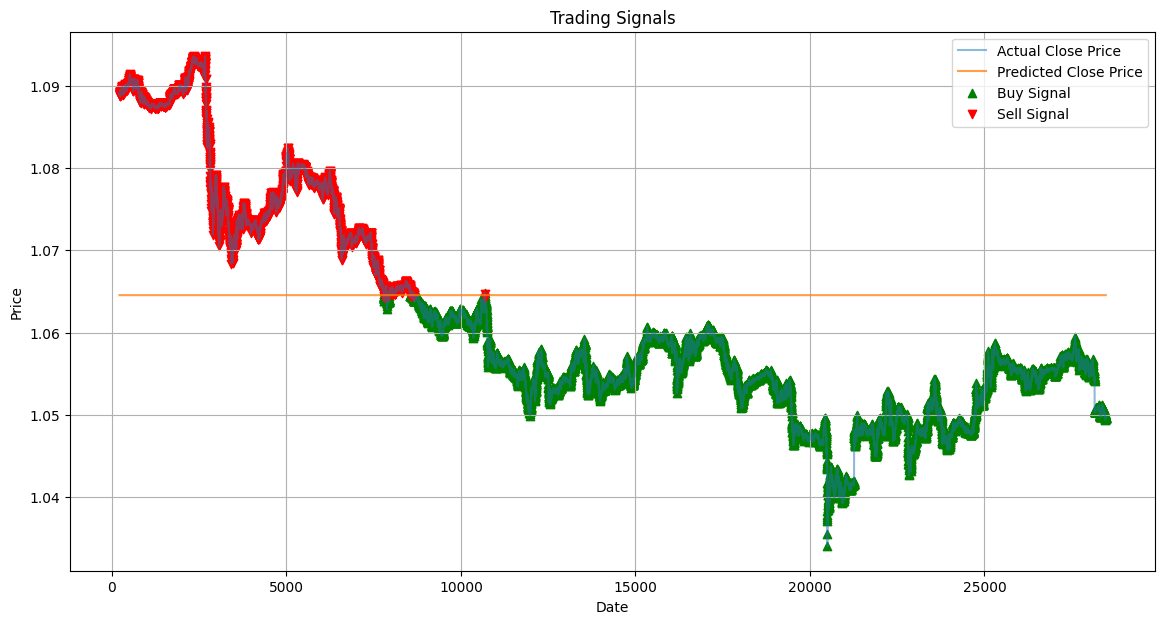

In [35]:
# Visualize Buy/Sell Signals
plt.figure(figsize=(14, 7))
plt.plot(data['close'], label='Actual Close Price', alpha=0.5)
plt.plot(data['Predicted_Close'], label='Predicted Close Price', alpha=0.75)
plt.scatter(data.index[data['Predicted_Signal'] == 1], data['close'][data['Predicted_Signal'] == 1],
            label='Buy Signal', marker='^', color='green')
plt.scatter(data.index[data['Predicted_Signal'] == -1], data['close'][data['Predicted_Signal'] == -1],
            label='Sell Signal', marker='v', color='red')
plt.title('Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [36]:
available_capital = 100000
risk_per_trade = 0.10  # 10% of capital per trade
capital_per_trade = available_capital * risk_per_trade

# Set stop-loss and take-profit thresholds (as percentage of the asset's price)
stop_loss_percentage = 0.02  # 2% stop-loss
take_profit_percentage = 0.05  # 5% take-profit

# Initialize position size to 0.02
data['Position_Size'] = 0.02

# Position size for Buy signals
data.loc[data['Signal'] == 1, 'Position_Size'] = capital_per_trade / data['close']

# For Sell signals, position size is negative (opposite of Buy)
data.loc[data['Signal'] == -1, 'Position_Size'] = -capital_per_trade / data['close']

# Integrate SVM predictions: Use a threshold to only take significant trades based on SVM predictions
threshold = 0.01  # Only take trades when SVM predicts a significant change (1%)

# Adjust position size for Buy signals if SVM prediction is positive and above threshold
data.loc[(data['Signal'] == 1) &
          (data['SVM_Prediction'] > data['SVM_Prediction'].shift(1)) &
          (data['SVM_Prediction'].pct_change() > threshold), 'Position_Size'] = capital_per_trade / data['close']

# Adjust position size for Sell signals if SVM prediction is negative and below threshold
data.loc[(data['Signal'] == -1) &
          (data['SVM_Prediction'] < data['SVM_Prediction'].shift(1)) &
          (data['SVM_Prediction'].pct_change() < -threshold), 'Position_Size'] = -capital_per_trade / data['close']

# Implement risk management: Set stop-loss and take-profit levels based on price change
data['Stop_Loss'] = data['close'] * (1 - stop_loss_percentage)
data['Take_Profit'] = data['close'] * (1 + take_profit_percentage)

# Simulate trade exits based on stop-loss or take-profit conditions
data['Exit'] = 0  # Default no exit
data.loc[data['close'] <= data['Stop_Loss'], 'Exit'] = -1  # Exit if price hits stop-loss (sell)
data.loc[data['close'] >= data['Take_Profit'], 'Exit'] = 1  # Exit if price hits take-profit (sell)

print(data[['close', 'Signal', 'Position_Size', 'SVM_Prediction', 'Stop_Loss', 'Take_Profit', 'Exit']].tail())


         close  Signal  Position_Size  SVM_Prediction  Stop_Loss  Take_Profit  \
28474  1.04977       0           0.02         1.06455   1.028775     1.102259   
28475  1.04965       0           0.02         1.06455   1.028657     1.102132   
28476  1.04962       0           0.02         1.06455   1.028628     1.102101   
28477  1.04963       0           0.02         1.06455   1.028637     1.102112   
28478  1.04957       0           0.02         1.06455   1.028579     1.102048   

       Exit  
28474     0  
28475     0  
28476     0  
28477     0  
28478     0  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\2082899205.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Position_Size'] = 0.02
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\2082899205.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Stop_Loss'] = data['close'] * (1 - stop_loss_percentage)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\2082899205.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\3648266891.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10001.613840935363' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)


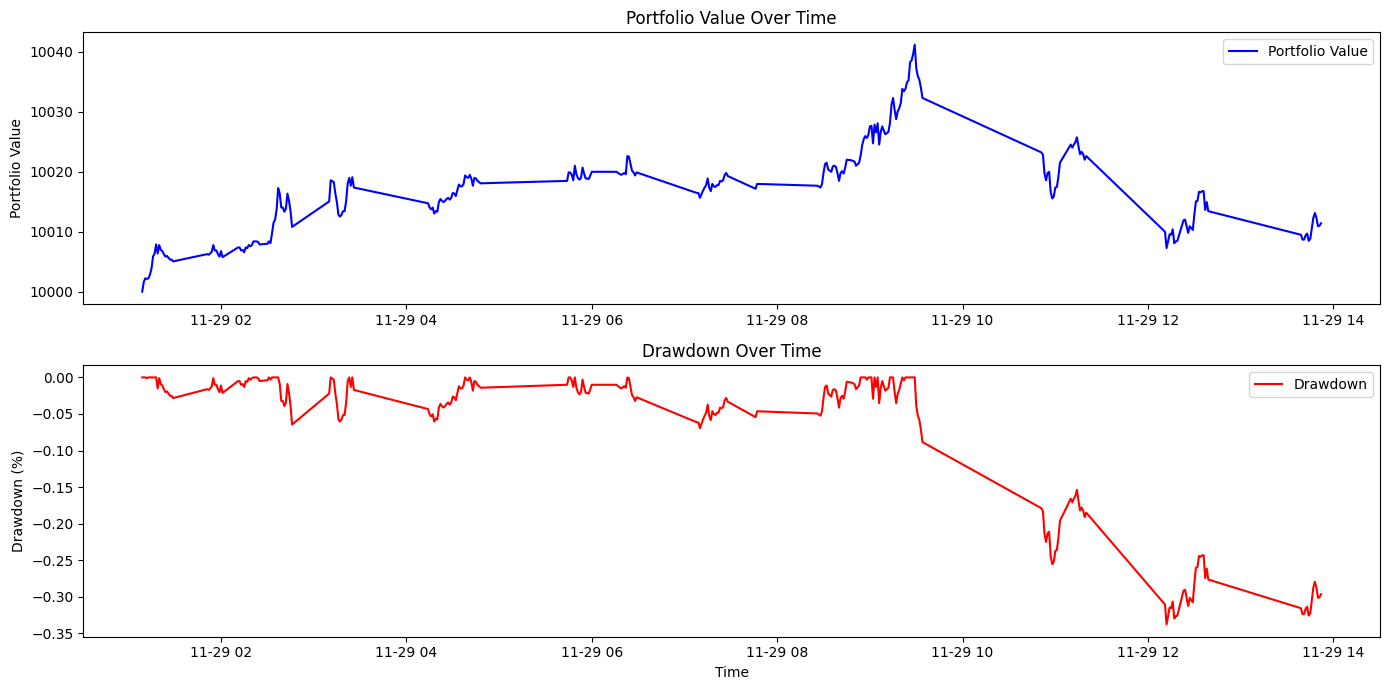

Maximum Drawdown: -0.34%
The maximum drawdown of -0.34% is within the acceptable range.


In [49]:

# Initial capital
initial_capital = 10000  # Starting portfolio value

# Calculate Returns from Close price
data['Returns'] = data['close'].pct_change()

# Initialize Portfolio Value column with initial capital
data['Portfolio_Value'] = initial_capital

# Backtest the strategy with the pre-trained model
data['Strategy_Returns'] = data['Returns'] * data['Predicted_Signal'].shift(1)

# Add stop-loss and take-profit conditions
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] < -0.01, -0.01, data['Strategy_Returns'])  # Stop-loss at -1%
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] > 0.02, 0.02, data['Strategy_Returns'])   # Take-profit at 2%


# Loop through the signals and update portfolio value
# for i in range(1, len(data)):
#     if data['Signal'].iloc[i] == 1:  # Buy signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 + data['Returns'].iloc[i])
#     elif data['Signal'].iloc[i] == -1:  # Sell signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 - data['Returns'].iloc[i])
#     else:  # Hold position
        # data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1]

for i in range(1, len(data)):
    prev_value = data['Portfolio_Value'].iloc[i - 1]
    strategy_return = data['Strategy_Returns'].iloc[i]
    data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)

# Calculate Drawdown
data['Peak'] = data['Portfolio_Value'].cummax()  # Track running maximum portfolio value
data['Drawdown'] = (data['Portfolio_Value'] - data['Peak']) / data['Peak'] * 100  # Calculate drawdown as a percentage

# Plot portfolio performance and drawdown
plt.figure(figsize=(14, 7))

# Plot portfolio value over time
plt.subplot(2, 1, 1)
plt.plot(data['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.title('Portfolio Value Over Time')
plt.ylabel('Portfolio Value')
plt.legend()

# Plot drawdown over time
plt.subplot(2, 1, 2)
plt.plot(data['Drawdown'], label='Drawdown', color='red')
plt.title('Drawdown Over Time')
plt.ylabel('Drawdown (%)')
plt.xlabel('Time')
plt.legend()

# Layout adjustment and display
plt.tight_layout()
plt.show()

# Maximum drawdown
max_drawdown = data['Drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Define acceptable drawdown threshold (you can adjust this value)
acceptable_drawdown_threshold = -6.0  # -6 is the maximum drawdown, i mean we are not settling for less

# Evaluate whether the drawdown is acceptable
if max_drawdown < acceptable_drawdown_threshold:
    print(f"The maximum drawdown of {max_drawdown:.2f}% exceeds the acceptable threshold of {acceptable_drawdown_threshold}%")
    print("Consider re-evaluating the portfolio strategy.")
else:
    print(f"The maximum drawdown of {max_drawdown:.2f}% is within the acceptable range.")


In [22]:
data.head()

,time,open,high,low,close,tick_volume,Adj Close,SMA50,SMA200,EMA50,...,Cumulative_Returns,Volume_SMA_7,Returns,Portfolio_Value,Momentum,Volatility,RSI,Predicted_Signal,Strategy_Returns,Cumulative_Returns_Strategy
284,2024-11-04 10:07:00,1.08934,1.08966,1.08934,1.08963,51,1.08963,1.089160,1.089469,1.089192,...,0.000330,42.000000,0.000275,NaN,0.00034,0.000140,50.0,1.05711,NaN,NaN
285,2024-11-04 10:08:00,1.08963,1.08971,1.08954,1.08954,26,1.08954,1.089161,1.089466,1.089205,...,0.000248,38.285714,-0.000083,99991.268605,0.00038,0.000129,50.0,1.05711,-0.000087,0.999913
286,2024-11-04 10:09:00,1.08954,1.08972,1.08954,1.08970,31,1.08970,1.089169,1.089464,1.089225,...,0.000395,36.000000,0.000147,100006.791012,0.00049,0.000132,50.0,1.05711,0.000155,1.000068
287,2024-11-04 10:10:00,1.08971,1.08990,1.08970,1.08986,40,1.08986,1.089181,1.089464,1.089250,...,0.000542,34.571429,0.000147,100022.313549,0.00059,0.000132,50.0,1.05711,0.000155,1.000223
288,2024-11-04 10:11:00,1.08987,1.08996,1.08986,1.08994,38,1.08994,1.089199,1.089464,1.089277,...,0.000615,36.000000,0.000073,100030.074882,0.00061,0.000131,50.0,1.05711,0.000078,1.000301


In [39]:
print(data[['Signal', 'close']].head(10))


     Signal    close
218       0  1.08902
219       0  1.08903
220       0  1.08913
221       0  1.08906
222       0  1.08906
223       0  1.08910
224       0  1.08899
225       0  1.08894
226       0  1.08900
227       0  1.08912


In [19]:

initial_capital = 100000  # Starting portfolio value

# Calculate Returns from Close price
data['Returns'] = data['close'].pct_change()

# Initialize Portfolio Value column with initial capital
data['Portfolio_Value'] = initial_capital

# Backtest the strategy with the pre-trained model
data['Strategy_Returns'] = data['Returns'] * data['Predicted_Signal'].shift(1)

# Add stop-loss and take-profit conditions
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] < -0.01, -0.01, data['Strategy_Returns'])  # Stop-loss at -1%
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] > 0.02, 0.02, data['Strategy_Returns'])   # Take-profit at 2%

# Loop through the signals and update portfolio value
# for i in range(1, len(data)):
#     if data['Signal'].iloc[i] == 1:  # Buy signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 + data['Returns'].iloc[i])
#     elif data['Signal'].iloc[i] == -1:  # Sell signal
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1] * (1 - data['Returns'].iloc[i])
#     else:  # Hold position
#         data.loc[data.index[i], 'Portfolio_Value'] = data['Portfolio_Value'].iloc[i - 1]

for i in range(1, len(data)):
    prev_value = data['Portfolio_Value'].iloc[i - 1]
    strategy_return = data['Strategy_Returns'].iloc[i]
    data.loc[data.index[i], 'Portfolio_Value'] = prev_value * (1 + strategy_return)

# Calculate Drawdown
data['Peak'] = data['Portfolio_Value'].cummax()  # Track running maximum portfolio value
data['Drawdown'] = (data['Portfolio_Value'] - data['Peak']) / data['Peak'] * 100  # Calculate drawdown as a percentage

# Plot portfolio performance and drawdown
plt.figure(figsize=(14, 7))

# Plot portfolio value over time
plt.subplot(2, 1, 1)
plt.plot(data['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.title('Portfolio Value Over Time')
plt.ylabel('Portfolio Value')
plt.legend()

# Plot drawdown over time
plt.subplot(2, 1, 2)
plt.plot(data['Drawdown'], label='Drawdown', color='red')
plt.title('Drawdown Over Time')
plt.ylabel('Drawdown (%)')
plt.xlabel('Time')
plt.legend()

# Layout adjustment and display
plt.tight_layout()
plt.show()

# Maximum drawdown
max_drawdown = data['Drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Define acceptable drawdown threshold (you can adjust this value)
acceptable_drawdown_threshold = -6.0

# Evaluate whether the drawdown is acceptable
if max_drawdown < acceptable_drawdown_threshold:
    print(f"The maximum drawdown of {max_drawdown:.2f}% exceeds the acceptable threshold of {acceptable_drawdown_threshold}%")
    print("Consider re-evaluating the portfolio strategy.")
else:
    print(f"The maximum drawdown of {max_drawdown:.2f}% is within the acceptable range.")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2236\2091549043.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Returns'] = data['close'].pct_change()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2236\2091549043.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Portfolio_Value'] = initial_capital


KeyError: 'Predicted_Signal'

In [ ]:
with open('svm_model_large.pkl', 'wb') as file:  # Use 'wb' for writing binary data
    pickle.dump(svm_model, file)

In [8]:
with open('../models/svm_model.pkl', 'rb') as file:
    svm_model = pickle.load(file)

try:
    print(svm_model.feature_names_in_)
except AttributeError:
    print("Feature names not available in the model.")

Feature names not available in the model.


In [9]:
data['Portfolio_Value'] = float(initial_capital)

NameError: name 'initial_capital' is not defined

In [45]:



def load_data(file_path):
    """
    Loads EUR/USD data from a CSV file and prepares it for backtesting.
    """
    data = pd.read_csv(file_path, index_col=0, parse_dates=True)
    data = data[['open', 'high', 'low', 'close']]
    data['Returns'] = data['close'].pct_change()
    data.dropna(inplace=True)
    return data

def add_indicators(data):
    """
    Adds moving average indicators and other features to the data.
    """
    data['SMA_5'] = data['close'].rolling(window=5).mean()
    data['SMA_10'] = data['close'].rolling(window=10).mean()
    data['SMA_20'] = data['close'].rolling(window=20).mean()
    data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
    data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
    data['Momentum'] = data['close'] - data['close'].shift(5)
    data['Volatility'] = data['Returns'].rolling(window=5).std()
    data['ROC_5'] = data['close'].pct_change(periods=5)
    data['Price_Change'] = data['close'].pct_change()
    data['Lag_1'] = data['close'].shift(1)
    data['Cumulative_Returns'] = (1 + data['Returns']).cumprod() - 1
    # Drop rows with missing values after feature creation
    data.dropna(inplace=True)
    return data

def calculate_metrics(data):
    """
    Calculates performance metrics for the backtesting results.
    """
    # Portfolio metrics
    data['Portfolio_Value'] = (1 + data['Strategy_Returns']).cumprod()
    peak = data['Portfolio_Value'].cummax()
    data['Drawdown'] = (data['Portfolio_Value'] - peak) / peak
    max_drawdown = data['Drawdown'].min()

    # Sharpe Ratio
    excess_returns = data['Strategy_Returns']  # Assuming risk-free rate = 0
    sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()

    # Winning and losing trades
    winning_trades = (data[data['Signal'] > 0]['Returns'] > 0).sum()
    losing_trades = (data[data['Signal'] < 0]['Returns'] < 0).sum()
    win_ratio = winning_trades / (winning_trades + losing_trades)
    loss_ratio = losing_trades / (winning_trades + losing_trades)
    total_winning_trades = winning_trades.sum()
    total_losing_trades = losing_trades.sum()

    return max_drawdown, sharpe_ratio, win_ratio, loss_ratio, total_winning_trades, total_losing_trades

def generate_svm_signals(data, model):
    """
    Generates trading signals using an SVM model.
    """
    features = ['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility',
                'ROC_5', 'Price_Change', 'Lag_1', 'Cumulative_Returns']

    # Ensure features exist in the data
    X = data[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Generate predictions
    data['Signal'] = model.predict(X_scaled)
    return data

def backtest_strategy(data, model_path):
    """
    Backtests a strategy using a pre-trained SVM model and moving average signals.
    """
    # Load the pre-trained model
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

    # Add indicators to the data
    data = add_indicators(data)

    # Generate signals using the SVM model
    data = generate_svm_signals(data, model)

    # Combine with moving average strategy
    data['MA_Signal'] = np.where(data['SMA_5'] > data['SMA_20'], 1, -1)
    data['Final_Signal'] = data['Signal'] * data['MA_Signal']

    # Calculate strategy returns
    data['Strategy_Returns'] = data['Returns'] * data['Final_Signal']

    # Calculate performance metrics
    max_drawdown, sharpe_ratio, win_ratio, loss_ratio, total_winning_trades, total_losing_trades  = calculate_metrics(data) # Unpack all 6 values here

    # Print performance metrics
    print(f"Portfolio Maximum Drawdown: {max_drawdown:.2%}")
    print(f"Portfolio Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Win Ratio: {win_ratio:.2%}")
    print(f"Loss Ratio: {loss_ratio:.2%}")

    print(f"Total Winning Trades: {total_winning_trades}")
    print(f"Total Losing Trades: {total_losing_trades}")

    return data

# Paths to data and model
synthetic_data_path = '/content/synthetic_eur_usd.csv'
real_data_path = '../datasets/EURUSD_M1_data.csv'
model_path = 'svm_model_large.pkl'

# Choose dataset
data = load_data(real_data_path)  # Change to `real_data_path` for real data

# Run backtesting
backtest_results = backtest_strategy(data, model_path)

# Save results
backtest_results.to_csv('../output/backtest_results.csv')
print("Backtesting completed. Results saved to '../output/backtest_results.csv'.")


Portfolio Maximum Drawdown: -0.24%
Portfolio Sharpe Ratio: 0.43
Win Ratio: 100.00%
Loss Ratio: 0.00%
Total Winning Trades: 421
Total Losing Trades: 0
Backtesting completed. Results saved to '../output/backtest_results.csv'.


In [21]:


# Fetch the data from Yahoo Finance (Euro/USD pair)
# ticker = "EURUSD=X"
# data = yf.download(ticker, start="2010-01-01", end="2024-01-01")
# data.drop_duplicates(inplace=True)


# Calculate features
data['Returns'] = data['close'].pct_change()
data['SMA_5'] = data['close'].rolling(window=5).mean()
data['SMA_10'] = data['close'].rolling(window=10).mean()
data['SMA_20'] = data['close'].rolling(window=20).mean()
data['EMA_5'] = data['close'].ewm(span=5, adjust=False).mean()
data['EMA_10'] = data['close'].ewm(span=10, adjust=False).mean()
data['Momentum'] = data['close'] - data['close'].shift(5)
data['Volatility'] = data['Returns'].rolling(window=5).std()
data['ROC_5'] = data['close'].pct_change(periods=5)
data['Price_Change'] = data['close'].pct_change()
data['Lag_1'] = data['close'].shift(1)
data['Cumulative_Returns'] = (1 + data['Returns']).cumprod() - 1
data['RSI'] = 100 - (100 / (1 + data['Returns'].rolling(window=14).mean() /
                             abs(data['Returns'].rolling(window=14).mean())))

# Remove infinite values (if any)
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Prepare data for model prediction
X = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'Momentum', 'Volatility', 'ROC_5', 'Price_Change', 'Lag_1', 'RSI']]
y = np.where(data['Returns'] > 0, 1, 0)  # 1 for up, 0 for down

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Load the pre-trained model
model_path = "../models/svm_model.pkl"
svm_model = joblib.load(model_path)

# Make predictions
y_pred = svm_model.predict(X_scaled)
data['Predicted_Signal'] = y_pred

# Backtest the strategy with the pre-trained model
data['Strategy_Returns'] = data['Returns'] * data['Predicted_Signal'].shift(1)

# Add stop-loss and take-profit conditions
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] < -0.01, -0.01, data['Strategy_Returns'])  # Stop-loss at -1%
data['Strategy_Returns'] = np.where(data['Strategy_Returns'] > 0.02, 0.02, data['Strategy_Returns'])   # Take-profit at 2%

# Cumulative returns of the strategy
data['Cumulative_Returns_Strategy'] = (1 + data['Strategy_Returns']).cumprod()

# Portfolio value calculation
initial_balance = 100000  # Initial portfolio value
data['Portfolio_Value'] = initial_balance * data['Cumulative_Returns_Strategy']

# Performance evaluation
winning_trades = data[data['Strategy_Returns'] > 0]
losing_trades = data[data['Strategy_Returns'] < 0]
total_trades = len(winning_trades) + len(losing_trades)  # Define total_trades here
net_profit = data['Portfolio_Value'].iloc[-1] - initial_balance
net_loss = -min(data['Portfolio_Value'].min() - initial_balance, 0)
sharpe_ratio = data['Strategy_Returns'].mean() / data['Strategy_Returns'].std() * np.sqrt(252)
win_ratio = (len(winning_trades) / total_trades) if total_trades else 0  # Avoid division by zero
loss_ratio = (len(losing_trades) / total_trades) if total_trades else 0
total_winning_trades = len(winning_trades)
total_losing_trades = len(losing_trades)
avg_winning_trade = winning_trades['Strategy_Returns'].mean()
avg_losing_trade = losing_trades['Strategy_Returns'].mean()


# Print performance metrics
print("Backtest Performance Metrics:")
print(f"Average Winning Trade: {avg_winning_trade:.4f}")
print(f"Average Losing Trade: {avg_losing_trade:.4f}")
print(f"Total Winning Trades: {total_winning_trades}")
print(f"Total Losing Trades: {total_losing_trades}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Win Ratio: {win_ratio:.2f}")
print(f"Loss Ratio: {loss_ratio:.2f}")
print(f"Net Profit: {net_profit:.2f}")
print(f"Net Loss: {net_loss:.2f}")

Backtest Performance Metrics:
Average Winning Trade: 0.0001
Average Losing Trade: -0.0001
Total Winning Trades: 4692
Total Losing Trades: 3425
Sharpe Ratio: 2.49
Win Ratio: 0.58
Loss Ratio: 0.42
Net Profit: 25208.94
Net Loss: 8.73


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2236\3377167863.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Returns'] = data['close'].pct_change()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2236\3377167863.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SMA_5'] = data['close'].rolling(window=5).mean()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2236\3377167863.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

# GBC model

In [50]:
import pandas as pd
import numpy as np

# import mplfinance as mpf  # Use mplfinance instead of matplotlib.finance
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.display import display
%matplotlib inline

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16088\3086597980.py:7: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display


In [7]:
data = pd.read_csv('../datasets/EURUSD_10000.csv')

In [8]:
df = pd.DataFrame(data)

In [9]:
# Duplicate the column
df['Adj Close'] = df['close']
df

,time,open,high,low,close,tick_volume,spread,real_volume,Adj Close
0,1683079200,1.10061,1.10138,1.10050,1.10108,848,0,0,1.10108
1,1683082800,1.10108,1.10206,1.10049,1.10173,1254,0,0,1.10173
2,1683086400,1.10174,1.10242,1.10129,1.10228,1523,0,0,1.10228
3,1683090000,1.10228,1.10258,1.10197,1.10253,1189,0,0,1.10253
4,1683093600,1.10253,1.10299,1.10251,1.10295,805,0,0,1.10295
...,...,...,...,...,...,...,...,...,...
9995,1733803200,1.05529,1.05613,1.05515,1.05532,1673,4,0,1.05532
9996,1733806800,1.05532,1.05576,1.05489,1.05564,1472,4,0,1.05564
9997,1733810400,1.05564,1.05598,1.05560,1.05574,1129,4,0,1.05574
9998,1733814000,1.05576,1.05625,1.05540,1.05619,1195,4,0,1.05619


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18512\1433065016.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[['open','high','low','close','Adj Close']] = df[['open','high','low','close','Adj Close']].applymap(lambda x: 1.0/x)


,time,open,high,low,close,tick_volume,spread,real_volume,Adj Close,return,timestamp
0,1683079200,1.10061,1.10138,1.10050,1.10108,848,0,0,1.10108,NaN,2023-05-03 02:00:00
1,1683082800,1.10108,1.10206,1.10049,1.10173,1254,0,0,1.10173,-0.031695,2023-05-03 03:00:00
2,1683086400,1.10174,1.10242,1.10129,1.10228,1523,0,0,1.10228,-0.026789,2023-05-03 04:00:00
3,1683090000,1.10228,1.10258,1.10197,1.10253,1189,0,0,1.10253,-0.012168,2023-05-03 05:00:00
4,1683093600,1.10253,1.10299,1.10251,1.10295,805,0,0,1.10295,-0.020430,2023-05-03 06:00:00


<Axes: xlabel='timestamp'>

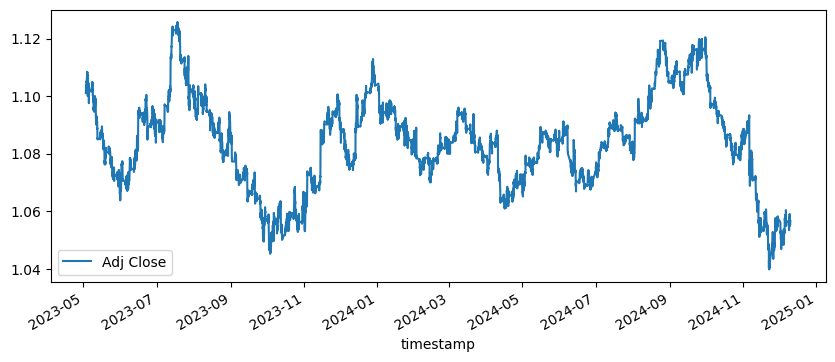

In [13]:
# Convert 'time' column from Unix timestamp to datetime
df['timestamp'] = pd.to_datetime(df['time'], unit='s')

# df.drop(['year','month','day','d'], inplace=True, axis=1)
df[['open','high','low','close','Adj Close']] = df[['open','high','low','close','Adj Close']].applymap(lambda x: 1.0/x)
display(df.head())

# Reset the index to make 'Date' a column
# df = df.reset_index()  # This line is added

df.plot(x='timestamp', y='Adj Close', figsize=(10,4))

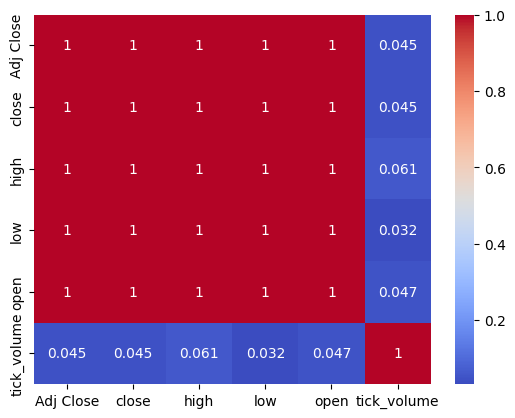

In [14]:
corr_matrix = df[['Adj Close', 'close', 'high', 'low', 'open', 'tick_volume']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='timestamp'>

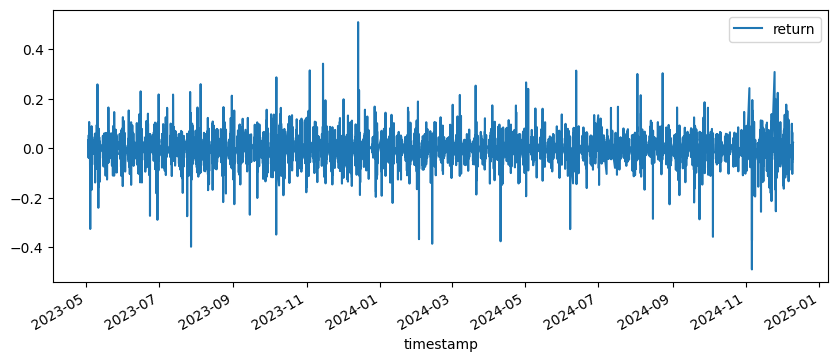

In [15]:
# Normalize aclose value
# We use this value to train model

df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
return_range = df['return'].max() - df['return'].min()
df['return'] = df['return'] / return_range

df.plot(x='timestamp', y='return', figsize=(10,4))

In [16]:
# Make label, 1 as rising price, 0 as falling price

df['label'] = df['return'].shift(-1)
df['label'] = df['label'].apply(lambda x: 1 if x>0.0 else 0)
df.dropna(inplace=True)
df.tail()

,time,open,high,low,close,tick_volume,spread,real_volume,Adj Close,return,timestamp,label
9995,1733803200,1.05529,1.05613,1.05515,1.05532,1673,4,0,1.05532,0.001505,2024-12-10 04:00:00,1
9996,1733806800,1.05532,1.05576,1.05489,1.05564,1472,4,0,1.05564,0.016048,2024-12-10 05:00:00,1
9997,1733810400,1.05564,1.05598,1.05560,1.05574,1129,4,0,1.05574,0.005015,2024-12-10 06:00:00,1
9998,1733814000,1.05576,1.05625,1.05540,1.05619,1195,4,0,1.05619,0.022568,2024-12-10 07:00:00,1
9999,1733817600,1.05618,1.05680,1.05608,1.05665,1354,4,0,1.05665,0.023069,2024-12-10 08:00:00,0


In [17]:
# Make training dataset

n_features = 60 # number of features

train_x = np.array([]).reshape([-1,n_features])
train_y = np.array([]).reshape([-1,1])
for index, row in df.iterrows():
    i = df.index.get_loc(index)
    if i<n_features:
        continue

    _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
    _y = df.iloc[i]['label'] # Use .iloc for positional indexing
    train_x = np.vstack((train_x, _x))
    train_y = np.vstack((train_y, _y))
train_y = train_y.reshape([-1])
print(train_x.shape)
print(train_y.shape)
print('%% of Class0 : %f' % (np.count_nonzero(train_y == 0)/float(len(train_y))))
print('%% of Class1 : %f' % (np.count_nonzero(train_y == 1)/float(len(train_y))))

(9939, 60)
(9939,)
% of Class0 : 0.503974
% of Class1 : 0.496026


In [18]:
# Define Model and fit
# Here we use 95% of data for training, and last 5% for testing

from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=0, learning_rate=0.0001, n_estimators=10000)

print("--- checkpoint 1 ---")
train_len = int(len(train_x)*0.95)
model.fit(train_x[:train_len], train_y[:train_len])
print("--- checkpoint 2 ---")
accuracy = model.score(train_x[train_len:], train_y[train_len:])
print('Testing Accuracy: %f' % accuracy)

--- checkpoint 1 ---
--- checkpoint 2 ---
Testing Accuracy: 0.531187


In [19]:
from sklearn.ensemble import GradientBoostingClassifier as GBClassifier
from sklearn.metrics import accuracy_score
import numpy as np  # Assuming numpy is being used for handling data


# Define the model with different learning rates
learning_rates = [0.001, 0.01, 0.0005, 0.0001, 0.0002, 0.0003, 0.0004, 0.02, 0.03, 0.04, 0.05, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009]

# Ensure the data length is sufficient for splitting
if len(train_x) < 2:
    raise ValueError("Training data is too small to be split.")

train_len = int(len(train_x) * 0.95)
test_len = len(train_x) - train_len

# Ensure train_len and test_len are correctly calculated
if train_len == 0 or test_len == 0:
    raise ValueError("Insufficient data for training and testing split.")

for lr in learning_rates:
    clf = GBClassifier(random_state=0, learning_rate=lr, n_estimators=10000)

    # Fit the model on the training data
    clf.fit(train_x[:train_len], train_y[:train_len])

    # Calculate accuracy on the test data
    y_pred = clf.predict(train_x[train_len:])
    y_test = train_y[train_len:]
    accuracy = accuracy_score(y_test, y_pred)
    clf_score = clf.score(train_x[train_len:], train_y[train_len:])
    print(f'Learning Rate: {lr}, Testing Accuracy: {accuracy:.4f}, clf_score: {clf_score}')

print('Code execution is over')


Learning Rate: 0.001, Testing Accuracy: 0.5151, clf_score: 0.5150905432595574
Learning Rate: 0.01, Testing Accuracy: 0.5111, clf_score: 0.5110663983903421
Learning Rate: 0.0005, Testing Accuracy: 0.5252, clf_score: 0.5251509054325956
Learning Rate: 0.0001, Testing Accuracy: 0.5312, clf_score: 0.5311871227364185
Learning Rate: 0.0002, Testing Accuracy: 0.5231, clf_score: 0.5231388329979879
Learning Rate: 0.0003, Testing Accuracy: 0.5312, clf_score: 0.5311871227364185
Learning Rate: 0.0004, Testing Accuracy: 0.5191, clf_score: 0.5191146881287726
Learning Rate: 0.02, Testing Accuracy: 0.5131, clf_score: 0.5130784708249497
Learning Rate: 0.03, Testing Accuracy: 0.5131, clf_score: 0.5130784708249497
Learning Rate: 0.04, Testing Accuracy: 0.4970, clf_score: 0.4969818913480885
Learning Rate: 0.05, Testing Accuracy: 0.5070, clf_score: 0.5070422535211268
Learning Rate: 0.002, Testing Accuracy: 0.5070, clf_score: 0.5070422535211268
Learning Rate: 0.003, Testing Accuracy: 0.5070, clf_score: 0.507

In [59]:
# Define Model and fit
# Here we use 95% of data for training, and last 5% for testing

from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=0, learning_rate=0.03, n_estimators=10000)

train_len = int(len(train_x)*0.95)
model.fit(train_x[:train_len], train_y[:train_len])

accuracy = model.score(train_x[train_len:], train_y[train_len:])
print('Testing Accuracy: %f' % accuracy)

Testing Accuracy: 0.496833


In [25]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

# Assuming train_x and train_y are your training data and labels
if len(train_x) < 2:
    raise ValueError("Training data is too small to be split.")

train_len = int(len(train_x) * 0.95)
test_len = len(train_x) - train_len

if train_len == 0 or test_len == 0:
    raise ValueError("Insufficient data for training and testing split.")

X_train, X_val, y_train, y_val = train_test_split(train_x[:train_len], train_y[:train_len], test_size=0.2, random_state=42)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.0005, 0.0001, 0.0002, 0.0003, 0.0004, 0.02, 0.03, 0.04, 0.05, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009],
    'n_estimators': [100, 500, 1000, 10000],
    'max_depth': [3, 4, 5]
}

xgb_model = xgb.XGBClassifier(random_state=0)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Fit the model without eval_set and eval_metric
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best parameters found: {best_params}")
print(f"Best cross-validation score: {best_score}")




Best parameters found: {'learning_rate': 0.0002, 'max_depth': 4, 'n_estimators': 1000}
Best cross-validation score: 0.5258856684534167


In [27]:
best_model = xgb.XGBClassifier(**best_params, random_state=0)

# Fit the model with eval_set for monitoring
best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],)

# Evaluate on the test set
y_pred = best_model.predict(train_x[train_len:])
y_test = train_y[train_len:]
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.4f}")

print('Code execution is over')


[0]	validation_0-logloss:0.69308
[1]	validation_0-logloss:0.69308
[2]	validation_0-logloss:0.69308
[3]	validation_0-logloss:0.69308
[4]	validation_0-logloss:0.69308
[5]	validation_0-logloss:0.69308
[6]	validation_0-logloss:0.69307
[7]	validation_0-logloss:0.69307
[8]	validation_0-logloss:0.69307
[9]	validation_0-logloss:0.69307
[10]	validation_0-logloss:0.69307
[11]	validation_0-logloss:0.69307
[12]	validation_0-logloss:0.69307
[13]	validation_0-logloss:0.69307
[14]	validation_0-logloss:0.69307
[15]	validation_0-logloss:0.69307
[16]	validation_0-logloss:0.69307
[17]	validation_0-logloss:0.69307
[18]	validation_0-logloss:0.69306
[19]	validation_0-logloss:0.69306
[20]	validation_0-logloss:0.69306
[21]	validation_0-logloss:0.69306
[22]	validation_0-logloss:0.69306
[23]	validation_0-logloss:0.69306
[24]	validation_0-logloss:0.69306
[25]	validation_0-logloss:0.69306
[26]	validation_0-logloss:0.69306
[27]	validation_0-logloss:0.69306
[28]	validation_0-logloss:0.69306
[29]	validation_0-loglos

In [22]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

# Assuming train_x and train_y are your training data and labels
if len(train_x) < 2:
    raise ValueError("Training data is too small to be split.")

train_len = int(len(train_x) * 0.95)
test_len = len(train_x) - train_len

if train_len == 0 or test_len == 0:
    raise ValueError("Insufficient data for training and testing split.")

X_train, X_val, y_train, y_val = train_test_split(train_x[:train_len], train_y[:train_len], test_size=0.2, random_state=42)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.0005, 0.0001, 0.0002, 0.0003, 0.0004, 0.02, 0.03, 0.04, 0.05, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009],
    'n_estimators': [100, 500, 1000, 10000],
    'max_depth': [3, 4, 5]
}

lgb_model = lgb.LGBMClassifier(random_state=0)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Fit the model without eval_set and eval_metric
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best parameters found: {best_params}")
print(f"Best cross-validation score: {best_score}")

best_model_lgb = lgb.LGBMClassifier(**best_params, random_state=0)

# Fit the model with eval_set for monitoring
best_model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])

# Evaluate on the test set
y_pred = best_model_lgb.predict(train_x[train_len:])
y_test = train_y[train_len:]
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.4f}")

print('Code execution is over')


[LightGBM] [Info] Number of positive: 3761, number of negative: 3792
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15300
[LightGBM] [Info] Number of data points in the train set: 7553, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497948 -> initscore=-0.008209
[LightGBM] [Info] Start training from score -0.008209
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,return,label,pred,won,pnl,equity
491,0.00003,1.0,0,False,-3.0,6105.0
492,0.00032,1.0,0,False,-32.0,6073.0
493,0.00010,1.0,1,True,10.0,6083.0
494,0.00045,1.0,1,True,45.0,6128.0
495,0.00046,1.0,1,True,46.0,6174.0


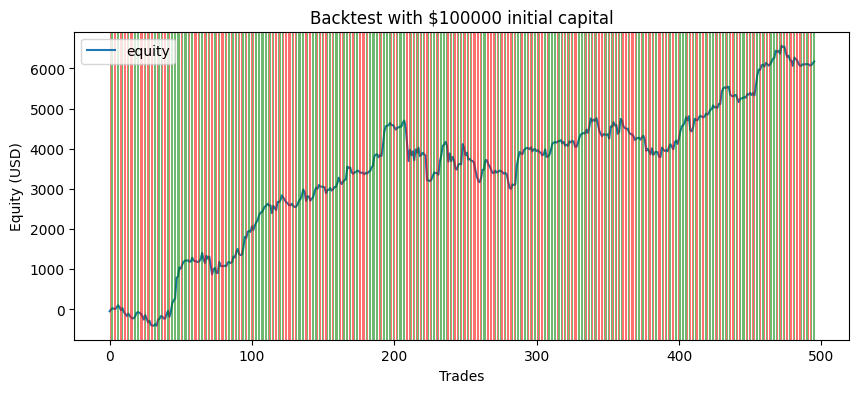

In [28]:
# Predict test data

pred = best_model.predict(train_x[train_len:])


# Calculate equity..

contracts  = 100000.0
commission = 0.0


df_trade = pd.DataFrame(train_x[train_len:,-1], columns=['return'])
df_trade['label']  = train_y[train_len:]
df_trade['pred']   = pred
df_trade['won']    = df_trade['label'] == df_trade['pred']
# df_trade['Date'] = df['Date'][train_len:]
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade)-1], inplace=True)

def calc_profit(row):
    if row['won']:
        return abs(row['return'])*contracts - commission
    else:
        return -abs(row['return'])*contracts - commission

df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()

display(df_trade.tail())
df_trade.plot(y='equity', figsize=(10,4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18512\2939523137.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


Net Profit            : $6174.00
Total win volume      : 22290
Total loss volume     : -16116
Number Winning Trades : 264
Number Losing Trades  : 227
Percent Profitable    : 53.77%
Avg Win Trade         : $84.432
Avg Los Trade         : $-70.996
Largest Win Trade     : $511.000
Largest Los Trade     : $-616.000
Profit Factor         : 1.38


<Axes: >

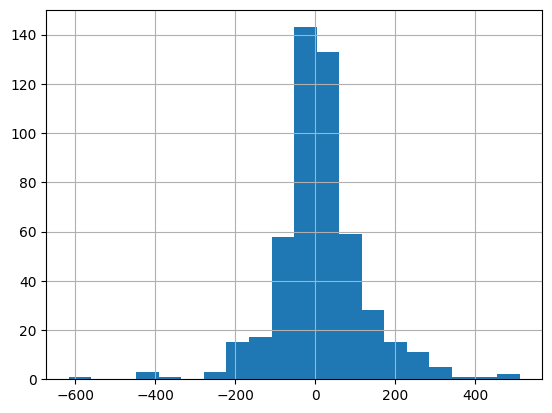

In [29]:
# Calculate summary of trades
n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
win_vol = df_trade[df_trade['pnl']>0.0]['pnl'].mean() * n_win_trades
loss_vol = df_trade[df_trade['pnl']<0.0]['pnl'].mean() * n_los_trades
# risk_exposure = df_trade['risk'].sum()
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
# print("Risk Exposure         : %d" % risk_exposure)
print("Total win volume      : %d" % win_vol)
print("Total loss volume     : %d" % loss_vol)
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

In [ ]:
df_trade.head()

,return,label,pred,won,pnl,equity
0,0.000179,1.0,0.0,False,-17.938430,-17.938430
1,-0.000045,0.0,0.0,True,4.485245,-13.453185
2,0.000260,1.0,0.0,False,-26.020333,-39.473518
3,-0.000063,0.0,0.0,True,6.282079,-33.191439
4,0.000377,1.0,1.0,True,37.704976,4.513537


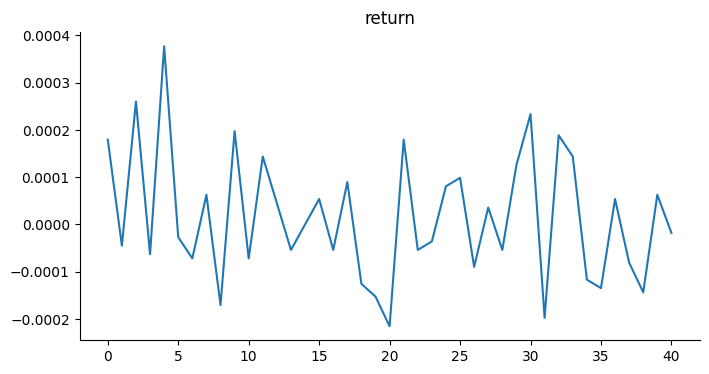

In [ ]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='line', figsize=(8, 4), title='return')
plt.gca().spines[['top', 'right']].set_visible(False)

In [70]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='hist', bins=20, title='pnl')
plt.gca().spines[['top', 'right',]].set_visible(False)

NameError: name 'df_trade' is not defined

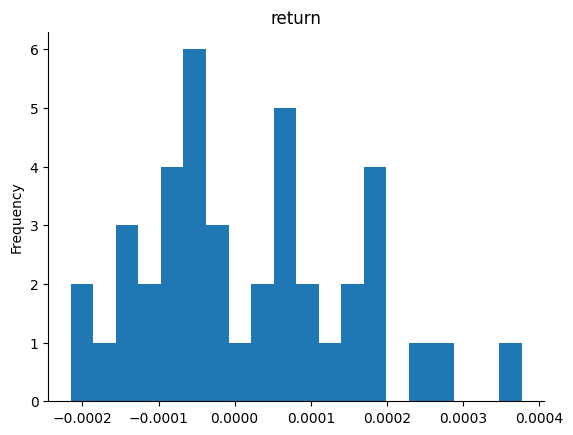

In [ ]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='hist', bins=20, title='return')
plt.gca().spines[['top', 'right',]].set_visible(False)

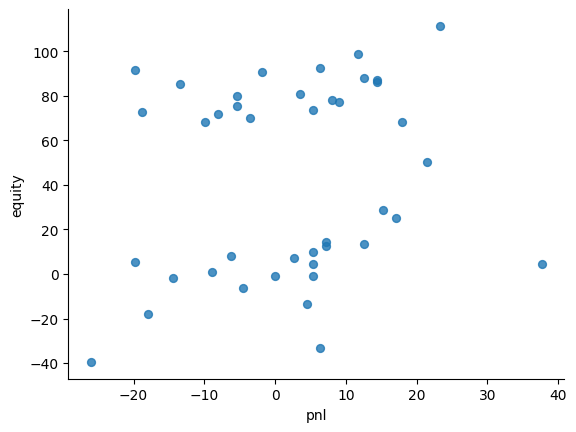

In [ ]:
# @title pnl vs equity

from matplotlib import pyplot as plt
df_trade.plot(kind='scatter', x='pnl', y='equity', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16260\2496445292.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_trade, x='pred', y='won', inner='stick', palette='Dark2')


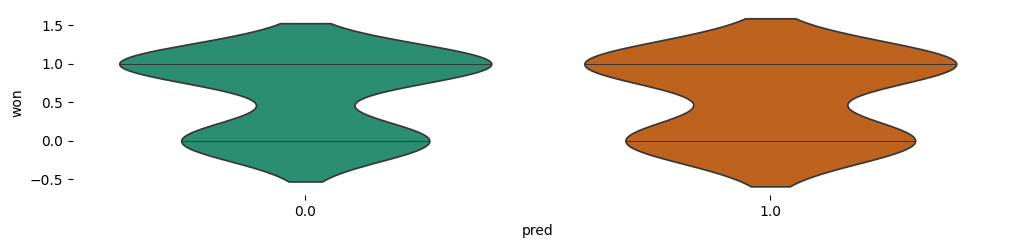

In [ ]:
# @title won vs pred

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_trade['won'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_trade, x='pred', y='won', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

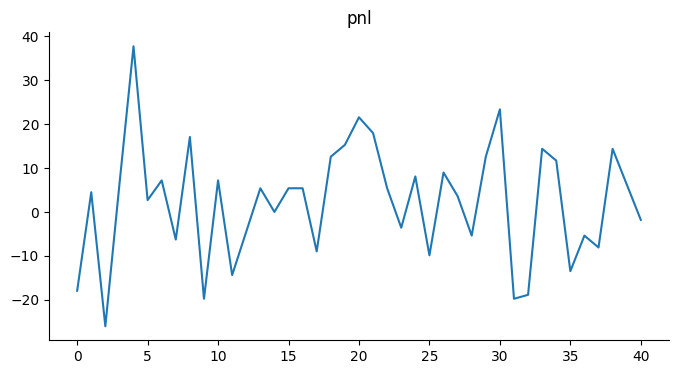

In [ ]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='line', figsize=(8, 4), title='pnl')
plt.gca().spines[['top', 'right']].set_visible(False)

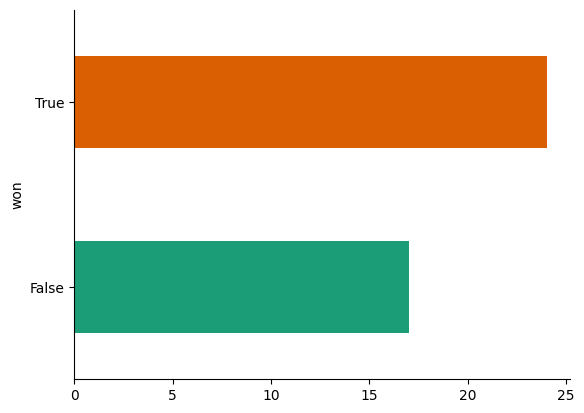

In [ ]:
# @title won

from matplotlib import pyplot as plt
import seaborn as sns
df_trade.groupby('won').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

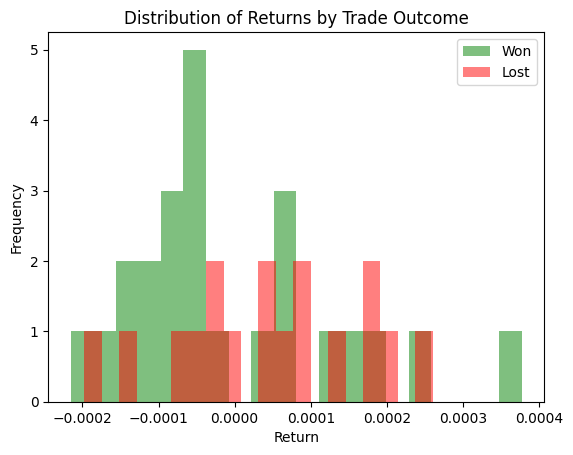

In [ ]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['return'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['return'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of Returns by Trade Outcome')
_ = plt.legend()

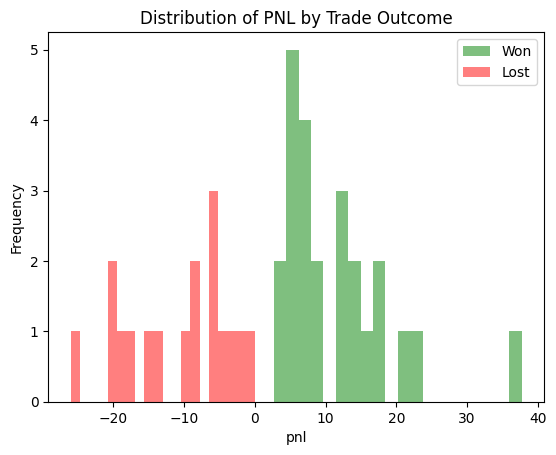

In [ ]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['pnl'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['pnl'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('pnl')
plt.ylabel('Frequency')
plt.title('Distribution of PNL by Trade Outcome')
_ = plt.legend()

In [30]:
from joblib import dump, load

# Save the model to a file
dump(best_model, 'nexo_xgb.joblib')

['nexo_xgb.joblib']

,return,label,pred,won,pnl,equity
36,0.000054,1.0,0.0,False,-5.389488,79.931833
37,-0.000081,0.0,1.0,False,-8.084003,71.847830
38,-0.000144,0.0,0.0,True,14.368156,86.215986
39,0.000063,1.0,1.0,True,6.285532,92.501518
40,-0.000018,0.0,1.0,False,-1.795951,90.705566


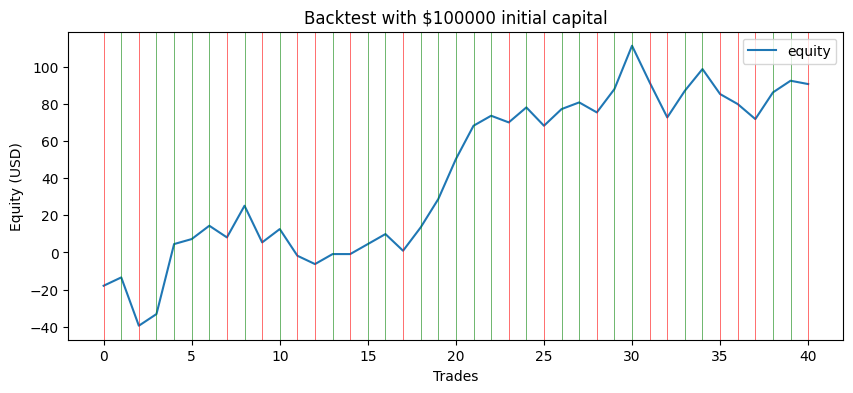

In [ ]:
# Load the model from the file
loaded_model = load('nexo.joblib')

# Make predictions with the loaded model
predictions = loaded_model.predict(train_x[train_len:])
# Calculate equity..

contracts  = 100000.0
commission = 0.0


df_trade = pd.DataFrame(train_x[train_len:,-1], columns=['return'])
df_trade['label']  = train_y[train_len:]
df_trade['pred']   = pred
df_trade['won']    = df_trade['label'] == df_trade['pred']
# df_trade['Date'] = df['Date'][train_len:]
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade)-1], inplace=True)

def calc_profit(row):
    if row['won']:
        return abs(row['return'])*contracts - commission
    else:
        return -abs(row['return'])*contracts - commission

df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()

display(df_trade.tail())
df_trade.plot(y='equity', figsize=(10,4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')
